# Week 2 — Notebook 1: Market Data Loading

In this notebook you will:
- Define project constants (paths, tickers, dates)
- Download OHLCV data for every market symbol and save it to `data/raw/`
- Explore the downloaded data and compute basic return statistics
- Compare multiple symbols with normalised return plots

Fill in every `# TODO` cell before moving to `technical_indicators.ipynb`.

---

## 0. Install & Import Libraries

In [29]:
 !pip install yfinance pandas numpy matplotlib  # uncomment on Colab / fresh env

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path

print('Libraries imported!')

Libraries imported!


---

## 1. Project Configuration

Define all constants that the project relies on. These same constants are used in every notebook and script this week, so get them right here first.

| Constant | Purpose |
|---|---|
| `BASE_DIR` | Root of the project (notebook's working directory) |
| `RAW_DIR` | `BASE_DIR/data/raw` — raw OHLCV CSVs |
| `PROCESSED_DIR` | `BASE_DIR/data/processed` — feature-engineered CSVs |
| `START_DATE` | Earliest date to download (`"2015-01-01"`) |
| `END_DATE` | `None` → today |
| `MARKET_SYMBOLS` | Dict: market name → list of Yahoo Finance ticker strings |

> 💡 Use `Path.cwd()` as the base when running inside a notebook.

In [30]:
from os.path import exists
# TODO 1.1 — Define directory paths and create them on disk
BASE_DIR      = Path.cwd() #cwd-current working directory folder
RAW_DIR       = BASE_DIR/'data'/'raw' #data/raw this folder will be storing the stock data
PROCESSED_DIR = BASE_DIR/'data'/'processed' #calculated indicators will be saved here
RAW_DIR.mkdir(parents=True,exist_ok=True) #creates folder on disk,parents=True creates the data folder if it doesn't exist,exist_ok=True don't show error if folder already exists
PROCESSED_DIR.mkdir(parents=True,exist_ok=True) #claculated indicators of this stock data will be stored here
print('RAW_DIR      :', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

RAW_DIR      : /content/data/raw
PROCESSED_DIR: /content/data/processed


In [31]:
# TODO 1.2 — Define the date range and market symbol universe
START_DATE =      '2015-01-01'
END_DATE   =      None #till today

#Load the market symbols in the readme as dictionary here
MARKET_SYMBOLS = {
    'india':  ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS', '^NSEI'],
    'us':     ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'SPY'],
    'crypto': ['BTC-USD', 'ETH-USD', 'BNB-USD'],
    'forex':  ['EURUSD=X', 'GBPUSD=X', 'USDINR=X'],
} #list of stocs of company in the country to download later.

print('Markets :', list(MARKET_SYMBOLS.keys())) #show the list of all the titles/labels
print('Symbols :', sum(len(v) for v in MARKET_SYMBOLS.values()), 'total') #go through all the iteration and add 5+5+3+3=16

Markets : ['india', 'us', 'crypto', 'forex']
Symbols : 16 total


In [32]:
# TODO 1.3 — Implement safe_symbol()
# Converts a ticker into a filesystem-safe filename stem.
# Rules: drop '^', replace '.' '-' '=' with '_'
# Examples:
#   '^NSEI'       -> 'NSEI'
#   'RELIANCE.NS' -> 'RELIANCE_NS'
#   'BTC-USD'     -> 'BTC_USD'
#   'EURUSD=X'    -> 'EURUSD_X'

def safe_symbol(symbol: str) -> str: #def-defined new funcn,safe_symbol-name of the funcn,symbol:str-funcn takes one input called symbol which is a text(str ensures text is input/output)
  return symbol.replace('^','').replace('.','_').replace('-','_').replace('=','_')
    #These special characters cause errors when saving files-so we have to change that.

# Smoke-test
assert safe_symbol('^NSEI')       == 'NSEI'
assert safe_symbol('RELIANCE.NS') == 'RELIANCE_NS'
assert safe_symbol('BTC-USD')     == 'BTC_USD'
assert safe_symbol('EURUSD=X')    == 'EURUSD_X'
print('safe_symbol() passed!')

safe_symbol() passed!


---

## 2. OHLCV Data Structure

Every downloaded file will have these columns (lowercase, normalised by us):

| Column | Description |
|---|---|
| `date` | Trading date |
| `open` | Price at market open |
| `high` | Intraday high |
| `low` | Intraday low |
| `close` | Price at market close |
| `adj_close` | Close adjusted for dividends and splits |
| `volume` | Shares / contracts traded |
| `symbol` | Ticker string (added by the download function) |

> The **close** price is used for all technical indicators. `adj_close` is preferred for long-term return calculations.

---

## 3. Download All Market Symbols → `data/raw/`

Implement the download pipeline step by step.

Each raw CSV must have lowercase column names, a `symbol` column, and be saved as `data/raw/<safe_symbol>.csv`.

In [33]:
# TODO 3.1 — Implement download_symbol()
# Downloads and cleans OHLCV data for a single ticker.
# Steps inside the function:
#   1. Call yf.download() with auto_adjust=False, progress=False
#   2. Raise ValueError if the result is empty
#   3. Flatten MultiIndex columns: keep only the first level
#      (yfinance sometimes returns a MultiIndex when downloading one symbol)
#   4. Reset the index so 'Date' becomes a regular column
#   5. Lowercase all column names; replace spaces with underscores
#   6. Add a 'symbol' column containing the ticker string

def download_symbol(symbol: str, start: str = START_DATE, end=END_DATE) -> pd.DataFrame:
    # 1. Call yf.download() function
    data=yf.download(symbol,start,end,auto_adjust=False,progress=False) #auto_adjust=False (download adj_close and close separately and progress=false signifies don't show the progress bar while downloading)

    # 2. Raise ValueError for check
    if data.empty:   #if yahoo finance returns nothing show error
      raise ValueError(f"No data returned for {symbol}")

    # 3. Flatten MultiIndex
    data.columns = [col[0] for col in data.columns]

    # 4. Reset index
    data=data.reset_index() #after downloading date is the index,we want date to be a regular column

    # 5. Normalise column names
    data.columns=[str(c).lower().replace(' ','_') for c in data.columns] #go through each colmn name one by one ,then lowercase its name and then replace space with underscore

    # 6. Add symbol column
    data['symbol']=symbol

    return data

# Quick test
test_df = download_symbol('SPY') #test with stock SPY
print(test_df.shape)
print(test_df.columns.tolist())  #shows all column names
test_df.head()

(2868, 8)
['date', 'adj_close', 'close', 'high', 'low', 'open', 'volume', 'symbol']


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.125031,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052597,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479141,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541168,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514206,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [34]:
# TODO 3.2 — Download every symbol and save to RAW_DIR
# Use a try/except so one failed ticker does not stop the loop.

for market, symbols in MARKET_SYMBOLS.items(): #market is India and symbol is reliance(inside market india) for eg
    for symbol in symbols: #go through each stock of india one by one
        try:
           df=download_symbol(symbol) #download that stock
           df.to_csv(RAW_DIR/f'{safe_symbol(symbol)}.csv',index=False) #saving BTC-USD.csv to BTC_USD.csv,index=false don't save row number in the file
           print(f'Saved{symbol}({len(df)}rows)')
        except Exception as e:
            print(f'Failed{symbol}:{e}') #if any stock shows error, print it ,then move to next stock, don't stop

SavedRELIANCE.NS(2817rows)
SavedTCS.NS(2817rows)
SavedINFY.NS(2817rows)
SavedHDFCBANK.NS(2817rows)
Saved^NSEI(2806rows)
SavedAAPL(2868rows)
SavedMSFT(2868rows)
SavedNVDA(2868rows)
SavedTSLA(2868rows)
SavedSPY(2868rows)
SavedBTC-USD(4168rows)
SavedETH-USD(3125rows)
SavedBNB-USD(3125rows)
SavedEURUSD=X(2969rows)
SavedGBPUSD=X(2970rows)
SavedUSDINR=X(2969rows)


---

## 4. Load & Explore a Single Symbol

Before computing indicators, get familiar with the raw data for one symbol.

In [43]:
# TODO 4.1 — Load SPY (or any symbol you like) from RAW_DIR
# Parse 'date' as datetime, sort ascending.
SYMBOL='SPY'
df=pd.read_csv(RAW_DIR/f'{safe_symbol(SYMBOL)}.csv',parse_dates=['date']) #parse_dates convert date column to proper datetime
df=df.sort_values('date').reset_index(drop=True) #sort frow oldest to lowest date, rest_index=true means reset row no to 0,1,2,..

print('Shape :', df.shape)
print('Dtypes:\n', df.dtypes)
df.head()

Shape : (2868, 8)
Dtypes:
 date         datetime64[ns]
adj_close           float64
close               float64
high                float64
low                 float64
open                float64
volume                int64
symbol               object
dtype: object


,date,adj_close,close,high,low,open,volume,symbol
0,2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900,SPY
1,2015-01-05,167.052567,201.720001,204.369995,201.350006,204.169998,169632600,SPY
2,2015-01-06,165.479095,199.820007,202.720001,198.860001,202.089996,209151400,SPY
3,2015-01-07,167.541214,202.309998,202.720001,200.880005,201.419998,125346700,SPY
4,2015-01-08,170.514221,205.899994,206.160004,203.990005,204.009995,147217800,SPY


In [46]:
  # TODO 4.2 — Compute and print the following statistics
#   1. Mean daily return (pct_change of close)
#   2. Daily return standard deviation (volatility)
#   3. Annualised volatility  →  daily_std * sqrt(252)
#   4. Total cumulative return over the full period
#   5. Date of the all-time high close
#   6. Date of the all-time low close

close   = df['close']
daily_returns=close.pct_change().dropna() #cal how much closing price changed each day in percentage,dropna()-removes first row which ahs no return
print(f"Mean Daily Return : {daily_returns.mean():.4%}") #avg of all daily returns
print(f"Daily Std (Volatility): {daily_returns.std():.4%}") #standard deviation average, sqrt of avg of variance
print(f"Annualised Volatility: {daily_returns.std()*np.sqrt(252):.4%}") #sqrt of variance *252 trading days in a year
print(f"Total Cummulative Return: {(close.iloc[-1]/close.iloc[0]-1):.4%}") #close.iloc[0]-closing price of start date of data, close.iloc[-1]-last closing price(today),then calculate cumulative return acc to formula
print(f"All Time High Date: {df.loc[close.idxmax(),'date'].date()}") #df.loc-goes to that row,idxmax()-goes to row no. where close was highest, 'date'-get that date of that row
print(f"All Time Low Date: {df.loc[close.idxmin(),'date'].date()}")


# print(...)

Mean Daily Return : 0.0517%
Daily Std (Volatility): 1.1163%
Annualised Volatility: 17.7214%
Total Cummulative Return: 268.2422%
All Time High Date: 2026-05-29
All Time Low Date: 2016-02-11


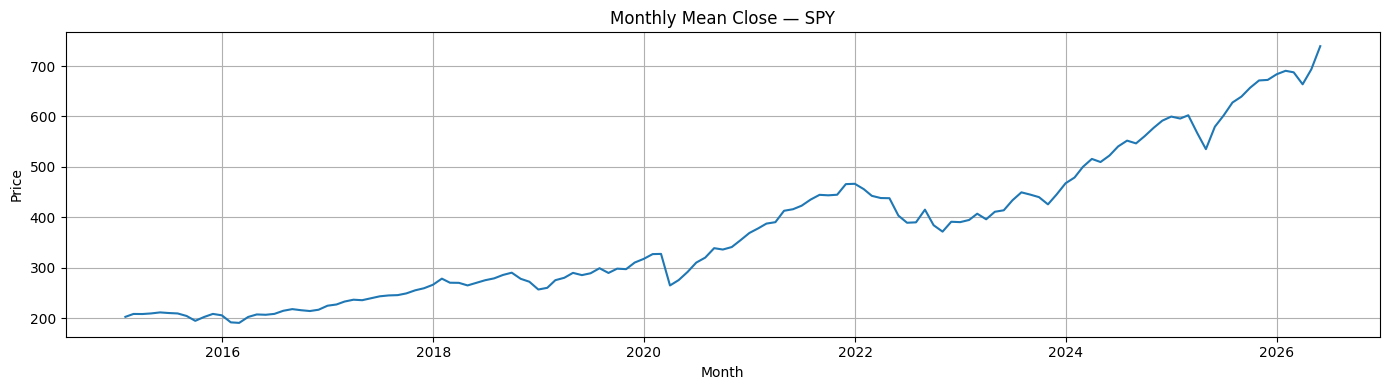

In [47]:
# TODO 4.3 — Resample close to monthly mean and plot as a line chart

monthly_close = df.set_index('date')['close'].resample('ME').mean() #new df with date as index and just take close colmn and then resample('ME') means group it by month and then take avg.

plt.figure(figsize=(14, 4))
plt.plot(monthly_close)
plt.title(f'Monthly Mean Close — {SYMBOL}')
plt.xlabel('Month'); plt.ylabel('Price')
plt.grid(True); plt.tight_layout(); plt.show()

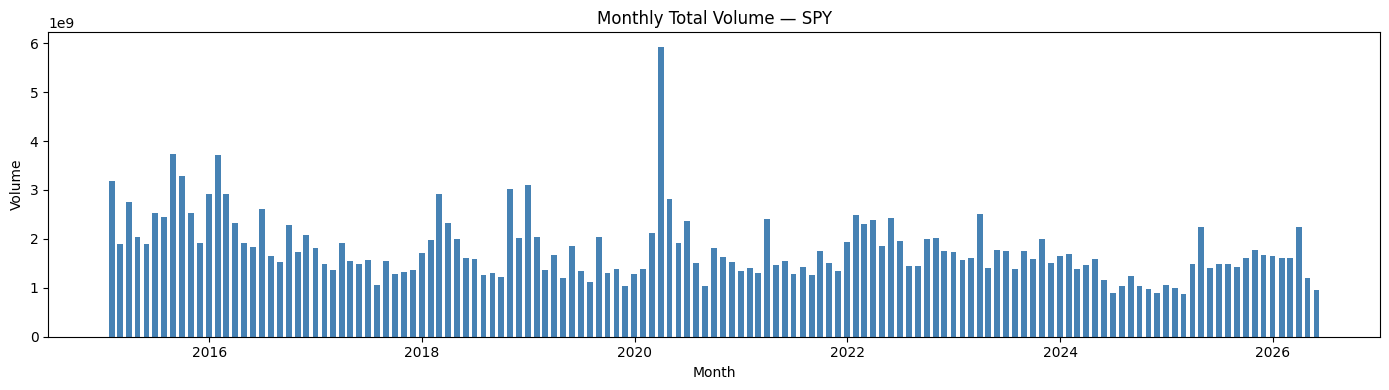

In [48]:
# TODO 4.4 — Resample volume to monthly total and plot as a bar chart

monthly_vol = df.set_index('date')['volume'].resample('ME').sum()

plt.figure(figsize=(14, 4))
plt.bar(monthly_vol.index,monthly_vol.values,width=20,color='steelblue')
plt.title(f'Monthly Total Volume — {SYMBOL}')
plt.xlabel('Month'); plt.ylabel('Volume')
plt.tight_layout(); plt.show()

---

## 5. Multi-Symbol Comparison

Normalised cumulative returns let you compare symbols regardless of their absolute price level. Dividing each series by its first value sets every series to start at 1.0.

In [49]:
# TODO 5.1 — Load the Close price for all US symbols into one DataFrame
# Each column = one symbol. Align on date index, forward-fill any gaps.

us_closes = {}
for sym in MARKET_SYMBOLS['us']:
  tmp=pd.read_csv(RAW_DIR/f'{safe_symbol(sym)}.csv',parse_dates=['date']) # load the saved csv file for that stock and store it in tmp
  tmp=tmp.set_index('date').sort_index() #make date as index and sort it from oldest to newest
  us_closes[sym]=tmp['close'] #takes only close price colmn and store it

us_df=pd.DataFrame(us_closes).ffill() #us_df stores closing price of all 5 US stocks side by side, ffill-if any date has missing value ,use previous day's value.
print(us_df.shape)
us_df.head()



(2868, 5)


,AAPL,MSFT,NVDA,TSLA,SPY
date,,,,,
2015-01-02,27.332500,46.759998,0.50325,14.620667,205.429993
2015-01-05,26.562500,46.330002,0.49475,14.006000,201.720001
2015-01-06,26.565001,45.650002,0.47975,14.085333,199.820007
2015-01-07,26.937500,46.230000,0.47850,14.063333,202.309998
2015-01-08,27.972500,47.590000,0.49650,14.041333,205.899994


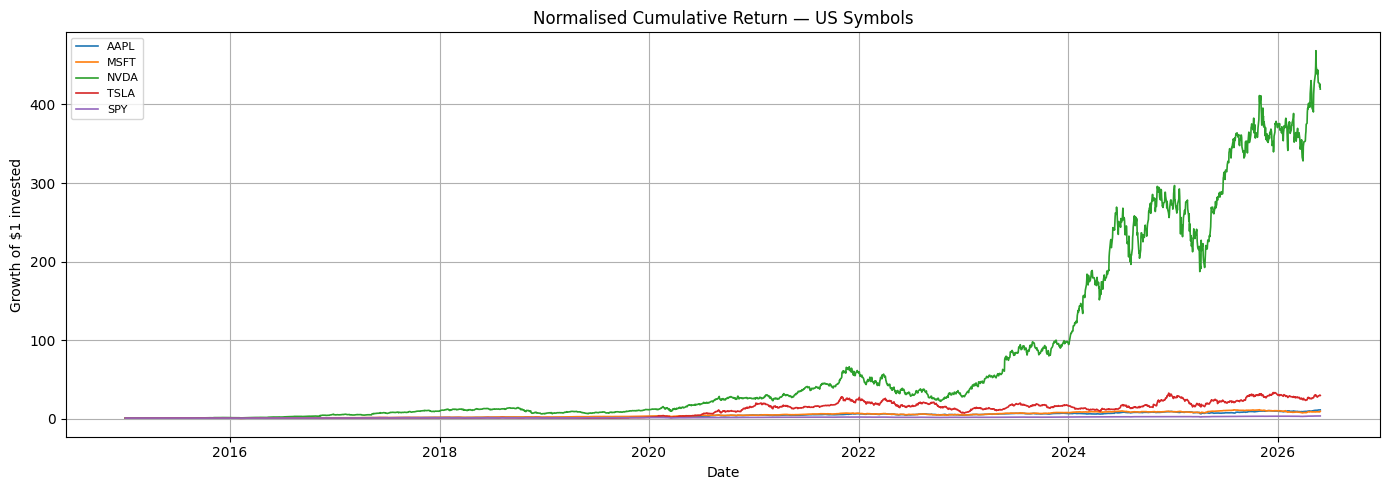

In [50]:
# TODO 5.2 — Normalise so each series starts at 1.0, then plot all on one chart
normalised=us_df/us_df.iloc[0]

plt.figure(figsize=(14,5))
for col in normalised.columns:
  plt.plot(normalised.index,normalised[col],label=col,linewidth=1.2)
plt.title('Normalised Cumulative Return — US Symbols')
plt.ylabel('Growth of $1 invested'); plt.xlabel('Date')
plt.legend(fontsize=8); plt.grid(True); plt.tight_layout(); plt.show()

(2817, 5)


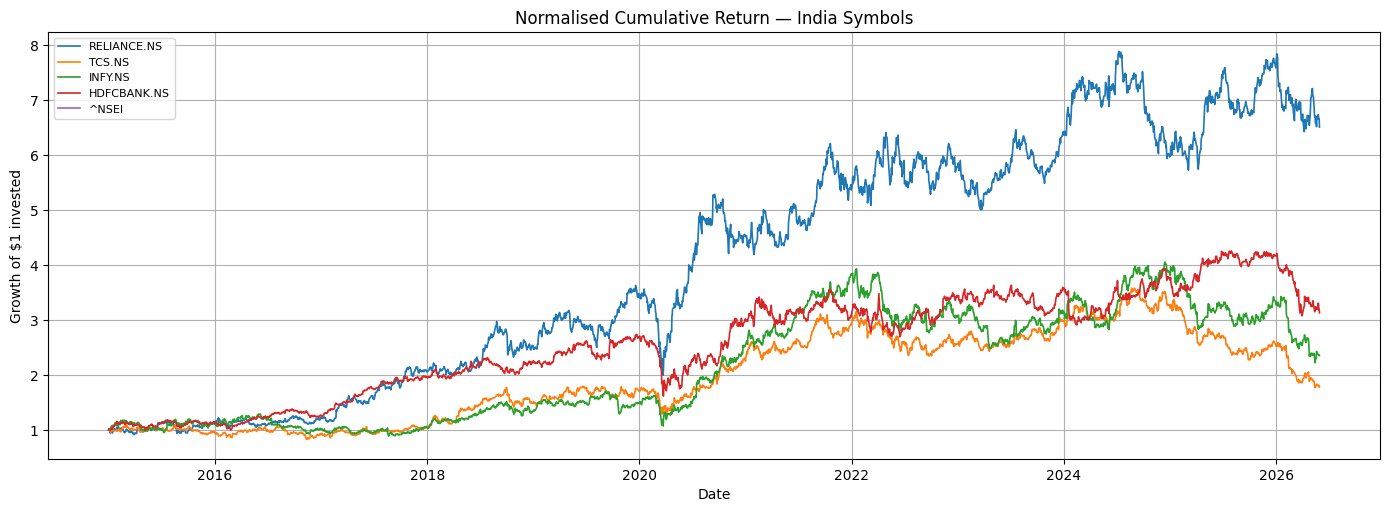

In [55]:
# TODO 5.3 — Repeat for India symbols

india_closes = {}
for sym in MARKET_SYMBOLS['india']:
  tmp=pd.read_csv(RAW_DIR/f'{safe_symbol(sym)}.csv',parse_dates=['date'])
  tmp=tmp.set_index('date').sort_index()
  india_closes[sym]=tmp['close']

india_df=pd.DataFrame(india_closes).ffill()
print(india_df.shape)
india_df.head()


# plot normalised series
normalised_india=india_df/india_df.iloc[0]
plt.figure(figsize=(14,5))
for col in normalised_india.columns:
  plt.plot(normalised_india.index,normalised_india[col],label=col,linewidth=1.2)
plt.xlabel('Date')
plt.ylabel('Growth of $1 invested')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.title('Normalised Cumulative Return — India Symbols')
plt.show()

---
